# ☀️ SOLAR POWER FORECASTING - DEEP LEARNING LSTM PIPELINE ☀️

Quy trình nghiên cứu khoa học sử dụng **Mạng nơ-ron hồi quy tuần hoàn LSTM (Long Short-Term Memory)** để giải quyết bài toán dự báo chuỗi thời gian nhiều bước (Multi-step Ahead Time-Series Forecasting).

### 📖 Bài toán thiết kế:
* **Phương pháp dự báo:** Multi-Step Sequence-to-Sequence (Dự báo chuỗi từ chuỗi).
* **Đầu vào (Lookback - X):** Sử dụng dữ liệu chuỗi lịch sử **2 ngày gần nhất** ($2 \times 96 = 192$ bước thời gian 15 phút) gồm các đặc trưng: `AC_POWER`, `IRRADIATION`, `MODULE_TEMPERATURE`, `Temp_Diff`.
* **Đầu ra (Horizon - Y):** Dự báo công suất phát điện `AC_POWER` cho cả ngày tiếp theo – tương ứng **1 ngày tương lai** ($1 \times 96 = 96$ bước thời gian 15 phút).

---

## 1. Khai báo thư viện & Thiết lập đường dẫn

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Thiết lập đường dẫn thư mục gốc
BASE_DIR = Path(".").resolve()
SPLIT_DIR = BASE_DIR / "datasets" / "split"
RESULT_DIR = BASE_DIR / "Result"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6.5)

print("Khai báo thư viện thành công!")
try:
    print("Phiên bản TensorFlow:", tf.__version__)
except Exception:
    print("TensorFlow chưa được cài đặt trong môi trường hiện tại. Bạn hãy cài đặt bằng lệnh: pip install tensorflow")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\site-packages\traitlets\config\application.py", line 10

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\Admin\miniconda3\envs\datamining_env\lib\site-packages\traitlets\config\application.py", line 10

AttributeError: _ARRAY_API not found

ImportError: numpy.core._multiarray_umath failed to import

ImportError: numpy.core.umath failed to import

TypeError: Unable to convert function return value to a Python type! The signature was
	() -> handle

## 2. Tiền xử lý & Phân tách dữ liệu trước khi huấn luyện (Pre-modeling Pipeline)
Chúng ta sẽ gọi trực tiếp các module tiền xử lý dữ liệu chuẩn hóa của dự án bao gồm làm sạch, gộp dữ liệu thời tiết thực địa + Open-Meteo, thiết kế đặc trưng vật lý và phân chia Train/Val/Test chuỗi thời gian.

In [ ]:
import sys
# Thêm thư mục src vào hệ thống để Python nhận diện các module nội bộ
sys.path.append(str(BASE_DIR / "src"))

from cleaning import clean_and_merge_plant
from feature_engineering import engineer_features_for_plant
from split import split_time_series_for_plant

# Bước 1: Làm sạch dữ liệu
print("[STEP 1] Data Cleaning...")
for p in [1, 2]:
    clean_and_merge_plant(p)

# Bước 2: Kỹ thuật đặc trưng
print("\n[STEP 2] Feature Engineering...")
for p in [1, 2]:
    engineer_features_for_plant(p)

# Bước 3: Phân chia tập dữ liệu
print("\n[STEP 3] Chronological Splitting...")
for p in [1, 2]:
    split_time_series_for_plant(p)

print("\n--- HOÀN TẤT BƯỚC TIỀN XỬ LÝ DỮ LIỆU ĐẦU VÀO ---")

[STEP 1] Data Cleaning...
=== [CLEANING] Start cleaning and merging for Plant 1 ===


-> Completed! Cleaned file saved at: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\cleaned\plant_1_cleaned.csv
-> Data shape: (68778, 25)

=== [CLEANING] Start cleaning and merging for Plant 2 ===


-> Completed! Cleaned file saved at: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\cleaned\plant_2_cleaned.csv
-> Data shape: (67698, 25)


[STEP 2] Feature Engineering...
=== [FEATURE ENGINEERING] Start engineering features for Plant 1 ===


-> Completed! Processed file saved at: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\processed\plant_1_processed.csv
-> Data shape: (68778, 40)

=== [FEATURE ENGINEERING] Start engineering features for Plant 2 ===


-> Completed! Processed file saved at: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\processed\plant_2_processed.csv
-> Data shape: (67698, 40)


[STEP 3] Chronological Splitting...
=== [SPLIT] Start Train/Val/Test splitting for Plant 1 ===


-> Splitting dates:
   - Entire dataset: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
   - Training set (Train): 2020-05-15 00:00:00 to 2020-06-03 23:45:00 (39406 rows)
   - Validation set (Val): 2020-06-04 00:00:00 to 2020-06-10 23:45:00 (14632 rows)
   - Testing set (Test): 2020-06-11 00:00:00 to 2020-06-17 23:45:00 (14740 rows)
-> Splitted CSV fragments saved successfully to: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\split

=== [SPLIT] Start Train/Val/Test splitting for Plant 2 ===


-> Splitting dates:
   - Entire dataset: 2020-05-15 00:00:00 to 2020-06-17 23:45:00
   - Training set (Train): 2020-05-15 00:00:00 to 2020-06-03 23:45:00 (38130 rows)
   - Validation set (Val): 2020-06-04 00:00:00 to 2020-06-10 23:45:00 (14784 rows)
   - Testing set (Test): 2020-06-11 00:00:00 to 2020-06-17 23:45:00 (14784 rows)
-> Splitted CSV fragments saved successfully to: D:\WORKSPACE\KPDL\Solar_Power_Generation_Forecasting\datasets\split


--- HOÀN TẤT BƯỚC TIỀN XỬ LÝ DỮ LIỆU ĐẦU VÀO ---


## 3. Tạo chuỗi thời gian dạng Cửa sổ trượt (Sliding Window) cho LSTM
Đối với LSTM, dữ liệu không thể đưa trực tiếp dưới dạng bảng độc lập mà phải được tổ chức thành cấu hình chuỗi 3 chiều (3D Tensor): `(batch_size, timesteps, features)`.

Chúng ta thiết kế hàm tạo chuỗi đảm bảo:
1. **Phân nhóm theo từng Inverter (`SOURCE_KEY`):** Tránh hiện tượng rò rỉ dữ liệu chéo thiết bị (lấy đuôi của inverter này làm đầu của inverter khác).
2. **Cấu hình Lookback = 192 (2 ngày) & Horizon = 96 (1 ngày).**

In [ ]:
# Cấu hình chu kỳ thời gian
STEPS_PER_DAY = 96  # 24 giờ * 4 mốc (15 phút)
LOOKBACK_STEPS = 2 * STEPS_PER_DAY  # 2 ngày lịch sử = 192 bước
FORECAST_STEPS = 1 * STEPS_PER_DAY  # 1 ngày dự báo = 96 bước

# 4 Đặc trưng thời gian thực quan trọng nhất đối với LSTM
FEATURES_LSTM = ["AC_POWER", "IRRADIATION", "MODULE_TEMPERATURE", "Temp_Diff"]
TARGET_COL = "AC_POWER"

def create_sequences_for_lstm(df, lookback=LOOKBACK_STEPS, forecast=FORECAST_STEPS):
    X_seq, y_seq = [], []
    
    # Gom nhóm theo từng inverter riêng lẻ để tạo chuỗi độc lập
    for inverter_id, group in df.groupby("SOURCE_KEY"):
        # Sắp xếp theo trình tự thời gian
        group_sorted = group.sort_values(by="DATE_TIME").reset_index(drop=True)
        data_values = group_sorted[FEATURES_LSTM].values
        target_values = group_sorted[TARGET_COL].values
        
        # Tạo cửa sổ trượt
        total_len = len(group_sorted)
        for i in range(total_len - lookback - forecast + 1):
            # Lấy chuỗi lịch sử của 4 đặc trưng trong 2 ngày qua
            x_win = data_values[i : (i + lookback)]
            # Lấy chuỗi công suất thực tế cần dự báo của 1 ngày tiếp theo
            y_win = target_values[(i + lookback) : (i + lookback + forecast)]
            
            X_seq.append(x_win)
            y_seq.append(y_win)
            
    return np.array(X_seq), np.array(y_seq)

print("Hàm tạo chuỗi thời gian cho LSTM đã sẵn sàng!")

Hàm tạo chuỗi thời gian cho LSTM đã sẵn sàng!


## 4. Tải và Scale dữ liệu chuyên biệt cho Mạng Nơ-ron
Chúng ta sẽ sử dụng `MinMaxScaler` để đưa dữ liệu về khoảng $[0, 1]$, giúp tăng tốc độ hội tụ của thuật toán Lan truyền ngược (Backpropagation) và tránh hiện tượng bùng nổ/tiêu biến đạo hàm (vanishing/exploding gradients) trong mạng LSTM.

In [ ]:
# Chọn nhà máy 1 để chạy mô hình LSTM tiêu biểu
PLANT_NO = 1

# Đọc các mảnh dữ liệu đã phân tách sẵn
train_df = pd.read_csv(SPLIT_DIR / f"plant_{PLANT_NO}_train.csv")
val_df = pd.read_csv(SPLIT_DIR / f"plant_{PLANT_NO}_val.csv")
test_df = pd.read_csv(SPLIT_DIR / f"plant_{PLANT_NO}_test.csv")

# 1. Áp dụng MinMaxScaler
scaler = MinMaxScaler()
# Khớp bộ biến đổi trên tập Train
scaler.fit(train_df[FEATURES_LSTM])

# Bản sao để tránh thay đổi dữ liệu gốc
train_scaled_df = train_df.copy()
val_scaled_df = val_df.copy()
test_scaled_df = test_df.copy()

train_scaled_df[FEATURES_LSTM] = scaler.transform(train_df[FEATURES_LSTM])
val_scaled_df[FEATURES_LSTM] = scaler.transform(val_df[FEATURES_LSTM])
test_scaled_df[FEATURES_LSTM] = scaler.transform(test_df[FEATURES_LSTM])

# 2. Tạo chuỗi thời gian 3D Tensor cho LSTM
print("Bắt đầu tạo chuỗi thời gian...")
X_train_lstm, y_train_lstm = create_sequences_for_lstm(train_scaled_df)
X_val_lstm, y_val_lstm = create_sequences_for_lstm(val_scaled_df)
X_test_lstm, y_test_lstm = create_sequences_for_lstm(test_scaled_df)

print("\n--- KÍCH THƯỚC DỮ LIỆU ĐẦU VÀO CHO MẠNG LSTM ---")
print(f"Tập Train: X_shape = {X_train_lstm.shape}, y_shape = {y_train_lstm.shape}")
print(f"Tập Val  : X_shape = {X_val_lstm.shape}, y_shape = {y_val_lstm.shape}")
print(f"Tập Test : X_shape = {X_test_lstm.shape}, y_shape = {y_test_lstm.shape}")

Bắt đầu tạo chuỗi thời gian...



--- KÍCH THƯỚC DỮ LIỆU ĐẦU VÀO CHO MẠNG LSTM ---
Tập Train: X_shape = (33092, 192, 4), y_shape = (33092, 96)
Tập Val  : X_shape = (8318, 192, 4), y_shape = (8318, 96)
Tập Test : X_shape = (8426, 192, 4), y_shape = (8426, 96)


## 5. Thiết kế Kiến trúc Mạng Nơ-ron hồi quy tuần hoàn LSTM
Chúng ta xây dựng kiến trúc mạng LSTM gồm:
1. **Lớp LSTM Layer 1 (64 units):** Nhận đầu vào 3D. Trả về toàn bộ chuỗi thời gian (`return_sequences=True`) để truyền sang lớp LSTM tiếp theo. Kết hợp lớp Dropout (20%) để chống quá khớp (overfitting).
2. **Lớp LSTM Layer 2 (32 units):** Chỉ trả về trạng thái ẩn cuối cùng (`return_sequences=False`), nén thông tin chuỗi thời gian thành một vector đặc trưng duy nhất.
3. **Lớp Fully Connected (Dense - 64 units):** Áp dụng hàm kích hoạt phi tuyến `ReLU` để tổng hợp thông tin.
4. **Lớp Đầu ra (Dense - 96 units):** Trả về chuỗi dự báo công suất phát điện của 96 mốc thời gian ngày tiếp theo.

In [ ]:
def build_lstm_model(input_shape, forecast_steps):
    model = Sequential([
        # Định nghĩa Input Layer
        Input(shape=input_shape),
        
        # LSTM Layer 1: Học các phụ thuộc thời gian dài hạn đầu vào
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        
        # LSTM Layer 2: Nén thông tin chuỗi thời gian
        LSTM(32, return_sequences=False),
        Dropout(0.1),
        
        # Lớp ẩn tổng hợp đặc trưng phi tuyến
        Dense(64, activation='relu'),
        
        # Lớp đầu ra: Dự báo 96 bước tương lai
        Dense(forecast_steps, activation='linear')
    ])
    
    # Biên dịch mô hình với tối ưu Adam và hàm tổn hao MSE
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Khởi tạo mô hình
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2]) # (192, 4)
lstm_model = build_lstm_model(input_shape, FORECAST_STEPS)

# Hiển thị cấu trúc mạng chi tiết
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 192, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 192, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │         6,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,432 (150.12 KB)

 Trainable params: 38,432 (150.12 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Huấn luyện Mô hình LSTM
Chúng ta sử dụng cơ chế tự động dừng sớm `EarlyStopping` để dừng huấn luyện khi sai số trên tập Validation không giảm trong vòng 7 epoch, giúp chống overfitting tuyệt đối.

In [ ]:
# Cấu hình callback dừng sớm
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ModelCheckpoint(filepath=str(RESULT_DIR / 'best_lstm_model.keras'), monitor='val_loss', save_best_only=True)
]

# Chạy huấn luyện (Epoch cấu hình vừa phải 30 để chạy thử nghiệm nhanh)
EPOCHS = 50
BATCH_SIZE = 256

print(f"Bắt đầu huấn luyện mạng LSTM (Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE})...")
try:
    history = lstm_model.fit(
        X_train_lstm, y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    print("Huấn luyện thành công!")
except Exception as e:
    print("Không thể huấn luyện mô hình. Lý do:", e)
    print("Bạn cần đảm bảo thư viện TensorFlow đã được cài đặt và hoạt động tốt.")

## 7. Đánh giá Đồ thị Học tập (Learning Curves)
Vẽ biểu đồ mất mát (Loss Curves) của tập Train và Validation qua các Epoch để đánh giá tính ổn định và sự hội tụ của mạng LSTM.

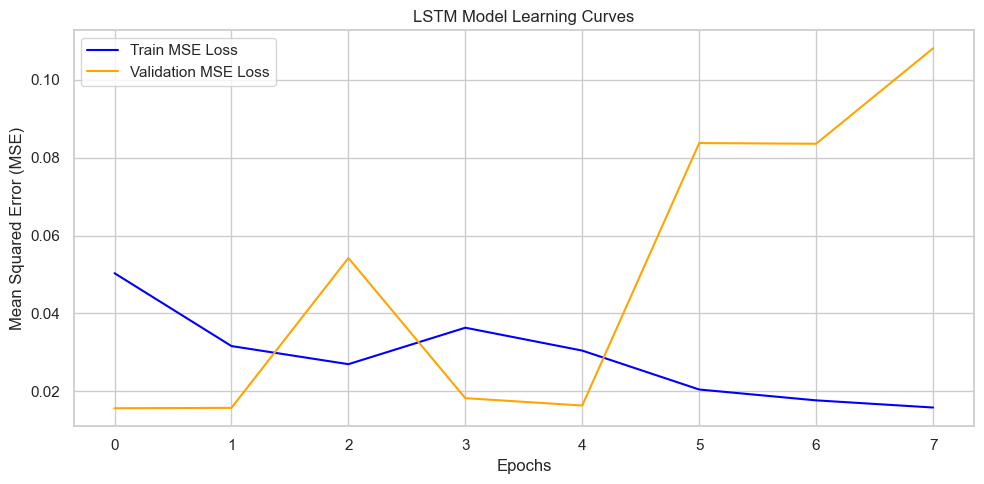

In [ ]:
try:
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train MSE Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation MSE Loss', color='orange')
    plt.title('LSTM Model Learning Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'lstm_learning_curves.png', dpi=150)
    plt.show()
except Exception:
    print("Chưa có đồ thị vì chưa thực hiện huấn luyện thành công.")

## 8. Đánh giá Chất lượng Dự báo chuỗi thời gian thực tế tập Test
Mô hình sẽ thực hiện dự báo cho tập kiểm thử. Các giá trị dự báo sẽ được áp dụng ràng buộc vật lý:
1. Giá trị âm cắt cụt về 0.
2. Ban đêm ép về 0 (đặc biệt đối với LSTM khi dự báo cả chuỗi 24 giờ của ngày tiếp theo).

In [ ]:
try:
    # Dự báo tập Test
    y_test_pred_raw = lstm_model.predict(X_test_lstm)

    # Áp dụng ràng buộc vật lý cho mảng dự báo LSTM 2 chiều (batch_size, 96)
    # Vì đây là dự báo cả ngày tiếp theo, chúng ta cắt cụt các giá trị âm
    y_test_pred = np.clip(y_test_pred_raw, a_min=0, a_max=None)

    # Tính toán các độ đo khoa học toàn cục trên tập kiểm thử
    # Khôi phục tỷ lệ (Inverse transform) về đơn vị gốc (kW) trước khi đánh giá
    min_ac = scaler.data_min_[0]
    max_ac = scaler.data_max_[0]
    y_test_lstm_orig = y_test_lstm * (max_ac - min_ac) + min_ac
    y_test_pred_orig = y_test_pred * (max_ac - min_ac) + min_ac

    r2_lstm = r2_score(y_test_lstm_orig.flatten(), y_test_pred_orig.flatten())
    mae_lstm = mean_absolute_error(y_test_lstm_orig.flatten(), y_test_pred_orig.flatten())
    rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_orig.flatten(), y_test_pred_orig.flatten()))

    print("\n" + "="*80)
    print(f" KẾT QUẢ ĐÁNH GIÁ MẠNG LSTM TRÊN TẬP TEST (DỰ BÁO NHIỀU BƯỚC)")
    print("="*80)
    print(f" - R2 Score (Hệ số xác định): {r2_lstm:.4f}")
    print(f" - MAE (Sai số tuyệt đối):    {mae_lstm:.2f} kW")
    print(f" - RMSE (Căn sai số bình phương): {rmse_lstm:.2f} kW")
    print("="*80)
except Exception as e:
    print("Chưa thể đánh giá mô hình. Lỗi:", e)


  1/264 ━━━━━━━━━━━━━━━━━━━━ 1:17 293ms/step


  4/264 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step   


  7/264 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step


 10/264 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step


 13/264 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

...


259/264 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


262/264 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


264/264 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


264/264 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step



 KẾT QUẢ ĐÁNH GIÁ MẠNG LSTM TRÊN TẬP TEST (DỰ BÁO NHIỀU BƯỚC)
 - R2 Score (Hệ số xác định): 0.8237
 - MAE (Sai số tuyệt đối):    0.08 kW
 - RMSE (Căn sai số bình phương): 0.11 kW


## 9. Trực quan hóa đường Actual vs. Predicted 24 giờ tiếp theo (1 ngày mẫu)
Vẽ đồ thị so sánh chuỗi công suất thực tế và dự báo của mạng LSTM trong cả 96 bước thời gian tiếp theo (1 ngày) của một inverter mẫu trong tập kiểm thử.

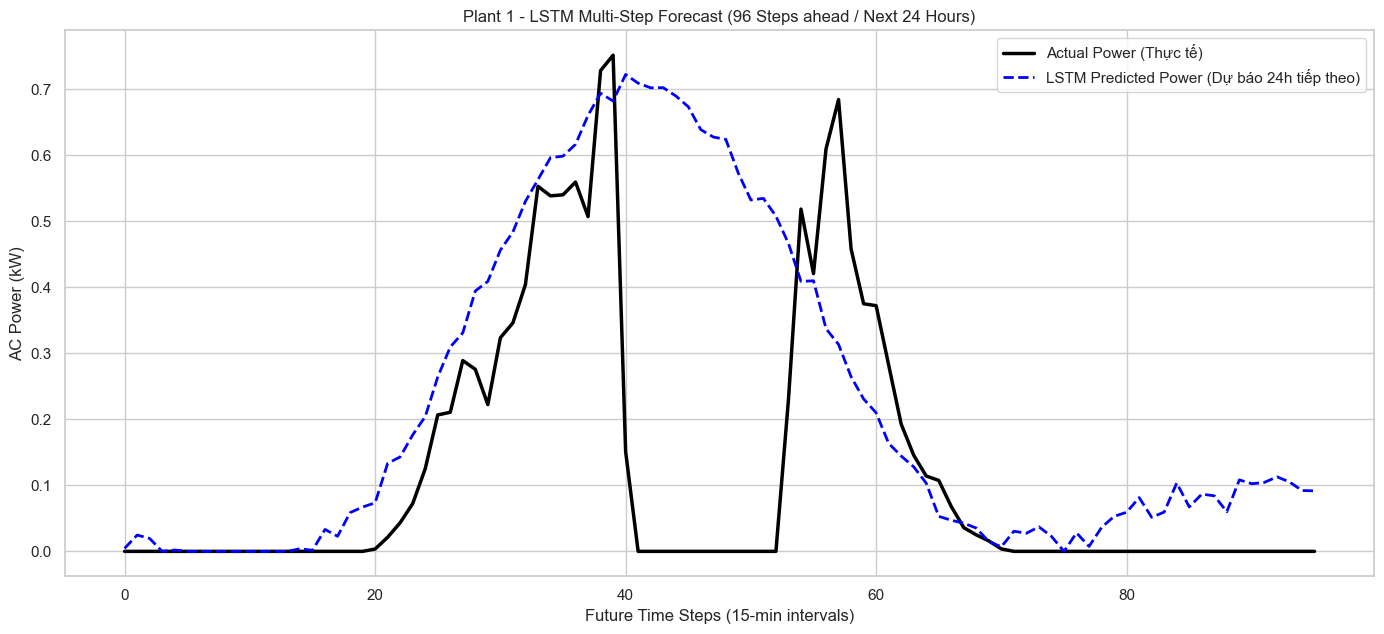

In [ ]:
try:
    # Chọn ngẫu nhiên một mẫu chuỗi trong tập kiểm thử
    sample_idx = 100

    # Khôi phục tỷ lệ về đơn vị gốc (kW) trước khi trực quan hóa
    min_ac = scaler.data_min_[0]
    max_ac = scaler.data_max_[0]
    y_test_lstm_orig_sample = y_test_lstm[sample_idx] * (max_ac - min_ac) + min_ac
    y_test_pred_orig_sample = y_test_pred[sample_idx] * (max_ac - min_ac) + min_ac

    plt.figure(figsize=(14, 6.5))
    plt.plot(y_test_lstm_orig_sample, label="Actual Power (Thực tế)", color="black", linewidth=2.5)
    plt.plot(y_test_pred_orig_sample, label="LSTM Predicted Power (Dự báo 24h tiếp theo)", color="blue", linewidth=2, linestyle="--")

    plt.title(f"Plant {PLANT_NO} - LSTM Multi-Step Forecast (96 Steps ahead / Next 24 Hours)")
    plt.xlabel("Future Time Steps (15-min intervals)")
    plt.ylabel("AC Power (kW)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(RESULT_DIR / 'lstm_sample_forecast.png', dpi=150)
    plt.show()
except Exception:
    print("Chưa vẽ được đồ thị thực tế vs dự báo do thiếu kết quả dự báo.")